# Karst Terrain Classification

---

## Phase 1: Project Setup and Data Loading

### 1. Import Libraries

In [1]:
# Core scientific computing
import numpy as np
import pandas as pd
from pathlib import Path
import time
import os
from matplotlib.animation import FuncAnimation, PillowWriter
from tqdm.auto import tqdm

# Visualization
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib import cm
from matplotlib.colors import LightSource, Normalize
from matplotlib.patches import FancyArrowPatch, Patch, Rectangle
import matplotlib.patches as mpatches
from matplotlib_scalebar.scalebar import ScaleBar
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

# Geospatial I/O and visualization
import rioxarray as rxr
import rasterio
from rasterio.plot import show as rio_show
from rasterio.plot import show_hist

try:
    import earthpy.plot as ep
    import earthpy.spatial as es
except ImportError:
    print("earthpy not available - using matplotlib LightSource for hillshade")
    ep = None
    es = None

try:
    import contextily as ctx
except ImportError:
    print("contextily not available - basemap features will be limited")
    ctx = None

# Color palettes for oceanography/terrain
try:
    import cmocean
except ImportError:
    print("cmocean not available - using default matplotlib colormaps")
    cmocean = None

# Topological data analysis
import cripser
from gtda.diagrams import (
    BettiCurve,
    PersistenceLandscape,
    PersistenceImage
)

# Machine learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Configure matplotlib for high-quality figures
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['font.family'] = 'sans-serif'

# Set seaborn style
sns.set_style('whitegrid')

print("✓ All libraries imported successfully")

d:\dev\karst-terrain-classification\.conda\Lib\site-packages\earthpy\__init__.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_string


✓ All libraries imported successfully


### 2. Define Paths and Constants

In [2]:
# Project root (relative path from notebook location)
PROJECT_ROOT = Path("../..").resolve()

# Data directories
DATA_ROOT = PROJECT_ROOT / "data"
EARTHSCAPE_ROOT = DATA_ROOT / "earthscape" / "earthscape_warren_rockfield"
PROCESSED_ROOT = DATA_ROOT / "processed" / "minimal_exploration"

# Output directory for presentation figures
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "presentation_visuals"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Exemplar tile ID (from compute_features.ipynb)
EXEMPLAR_TILE_ID = "256_50_11"

# Geologic class names (from EarthScape dataset)
CLASS_NAMES = [
    "Artificial Fill (af1)",
    "Alluvium (Qal)",
    "Alluvial Fans (Qaf)",
    "Alluvial Terraces (Qat)",
    "Colluvium (Qc)",
    "Colluvial Accumulations (Qca)",
    "Residuum (Qr)"
]

# Color mapping for consistent visualization across charts
METHOD_COLORS = {
    'traditional': 'steelblue',
    'persimage': 'green',
    'betti100': 'lightgreen',
    'betti200': 'lightgreen',
    'ecc50': 'lightcoral',
    'ecc200': 'lightcoral',
    'landscape': 'gold',
    'ph_directional': 'gold'
}

print(f"Project root: {PROJECT_ROOT}")
print(f"Exemplar tile: {EXEMPLAR_TILE_ID}")
print(f"Output directory: {OUTPUT_DIR}")

Project root: D:\dev\karst-terrain-classification
Exemplar tile: 256_50_11
Output directory: D:\dev\karst-terrain-classification\outputs\presentation_visuals


### 3. Load Performance Metrics (F1-scores and Timing)

In [3]:
# Load cross-validation results
cv_results_path = PROCESSED_ROOT / "testbed_cv_results.npy"

if cv_results_path.exists():
    cv_results = np.load(cv_results_path, allow_pickle=True).item()
    print("✓ Loaded CV results")
    
    # Extract F1-scores using dictionary comprehension
    f1_scores = {
        feature_type: {
            'mean': score_values.mean(),
            'std': score_values.std(),
            'scores': score_values
        }
        for feature_type, score_values in cv_results.get('scores', {}).items()
        if isinstance(score_values, np.ndarray)
    }
    
    # Display summary
    if f1_scores:
        f1_df = pd.DataFrame([
            {'Feature Type': ft, 'Mean F1': scores['mean'], 'Std F1': scores['std']}
            for ft, scores in f1_scores.items()
        ]).sort_values('Mean F1', ascending=False)
        print("\nF1-Score Summary:")
        print(f1_df.to_string(index=False))
else:
    print("⚠ CV results not found")
    f1_scores = None

✓ Loaded CV results

F1-Score Summary:
  Feature Type  Mean F1   Std F1
     persimage 0.692471 0.102158
   traditional 0.667700 0.146008
      betti200 0.612691 0.108980
      betti100 0.611688 0.094951
     landscape 0.611467 0.080847
         ecc50 0.589500 0.110284
        ecc200 0.563331 0.094829
ph_directional 0.540606 0.088642


In [4]:
# Load timing data
timing_path = PROCESSED_ROOT / "testbed_timing.npy"

if timing_path.exists():
    timing_data = np.load(timing_path, allow_pickle=True).item()
    print("✓ Loaded timing data")
    print(f"  Available timing info for: {list(timing_data.keys())}")
else:
    print("⚠ Timing data not found")
    timing_data = None

✓ Loaded timing data
  Available timing info for: ['traditional', 'ecc50', 'ecc200', 'ph_compute', 'betti100', 'betti200', 'landscape', 'persimage', 'ph_directional']


### 4. Load Exemplar DEM Tile

In [5]:
# Construct path to exemplar DEM
dem_path = EARTHSCAPE_ROOT / "patches" / f"{EXEMPLAR_TILE_ID}_dem.tif"

if dem_path.exists():
    # Load DEM using rioxarray for geospatial metadata
    dem_xr = rxr.open_rasterio(dem_path, masked=True)
    
    # Extract as numpy array
    dem_array = dem_xr.values[0]  # Remove band dimension
    
    # Get metadata
    crs = dem_xr.rio.crs
    bounds = dem_xr.rio.bounds()
    transform = dem_xr.rio.transform()
    
    print(f"✓ Loaded exemplar DEM: {EXEMPLAR_TILE_ID}_dem.tif")
    print(f"  Shape: {dem_array.shape}")
    print(f"  CRS: {crs}")
    print(f"  Elevation range: {np.nanmin(dem_array):.2f} - {np.nanmax(dem_array):.2f} m")
else:
    raise FileNotFoundError(f"Exemplar DEM not found at {dem_path}")

✓ Loaded exemplar DEM: 256_50_11_dem.tif
  Shape: (256, 256)
  CRS: EPSG:3089
  Elevation range: 601.86 - 635.39 m


### 5. Load Labels for Exemplar Tile

In [6]:
# Load all labels
labels_path = PROCESSED_ROOT / "testbed_labels.npy"

if labels_path.exists():
    labels_all = np.load(labels_path)
    print(f"✓ Loaded labels: shape {labels_all.shape}")
    
    # Using tile "256_50_11" as exemplar (index 10 in the dataset)
    exemplar_label_idx = 10
    exemplar_label = labels_all[exemplar_label_idx]
    
    # Decode one-hot label
    class_idx = np.argmax(exemplar_label)
    class_name = CLASS_NAMES[class_idx]
    
    print(f"\n✓ Exemplar tile label: {class_name}")
else:
    raise FileNotFoundError(f"Labels not found at {labels_path}")

✓ Loaded labels: shape (100, 7)

✓ Exemplar tile label: Alluvium (Qal)


### 6. Load Pre-computed Features

In [7]:
# Load all pre-computed feature types
feature_files = {
    'traditional': 'testbed_features_traditional.npy',
    'ecc50': 'testbed_features_ecc50.npy',
    'betti100': 'testbed_features_betti100.npy',
    'landscape': 'testbed_features_landscape.npy',
    'persimage': 'testbed_features_persimage.npy',
    'ph_directional': 'testbed_features_ph_directional.npy'
}

# Load features with dictionary comprehension
features = {
    name: np.load(PROCESSED_ROOT / filename)
    for name, filename in feature_files.items()
    if (PROCESSED_ROOT / filename).exists()
}

# Display loaded features
for name, feat_array in features.items():
    print(f"✓ Loaded {name}: shape {feat_array.shape}")

# Extract exemplar features
exemplar_features = {name: feat[exemplar_label_idx] for name, feat in features.items()}
print(f"\n✓ Extracted features for exemplar tile (index {exemplar_label_idx})")

✓ Loaded traditional: shape (100, 150)
✓ Loaded ecc50: shape (100, 50)
✓ Loaded betti100: shape (100, 200)
✓ Loaded landscape: shape (100, 1100)
✓ Loaded persimage: shape (100, 5000)
✓ Loaded ph_directional: shape (100, 800)

✓ Extracted features for exemplar tile (index 10)


---

## Phase 2: Act I - The Problem

**Goal:** Establish the core question: "Can the shape of the land tell us what it's made of?"

### Helper Functions

In [8]:
def generate_hillshade(dem_array, azimuth=315, altitude=45):
    """Generate hillshade from DEM using earthpy or matplotlib's LightSource."""
    # Handle NaN values
    dem_clean = np.copy(dem_array)
    mask = ~np.isfinite(dem_clean)
    if mask.any():
        dem_clean[mask] = np.nanmin(dem_clean)
    
    # Use earthpy if available (more sophisticated)
    if es is not None:
        try:
            hillshade = es.hillshade(dem_clean, azimuth=azimuth, altitude=altitude)
            return hillshade
        except:
            pass  # Fall back to matplotlib
    
    # Fallback to matplotlib LightSource
    ls = LightSource(azdeg=azimuth, altdeg=altitude)
    return ls.hillshade(dem_clean, vert_exag=1.0, dx=1.0, dy=1.0)

def add_north_arrow(ax, x=0.95, y=0.95, arrow_length=0.08, size_scale=1.0):
    """Add a north arrow to a matplotlib axes."""
    # Scale parameters
    width = 3/1000 * size_scale
    head_width = 10/1000 * size_scale
    head_length = 10/1000 * size_scale
    
    arrow = mpatches.FancyArrow(
        x, y - arrow_length, 0, arrow_length,
        width=width, head_width=head_width, head_length=head_length,
        transform=ax.transAxes, color='white', edgecolor='black', 
        linewidth=1.5, zorder=1000
    )
    ax.add_patch(arrow)
    ax.text(x, y + 0.02, 'N', transform=ax.transAxes,
            ha='center', va='bottom', fontsize=12, fontweight='bold',
            color='white', zorder=1001,
            path_effects=[plt.matplotlib.patheffects.withStroke(linewidth=3, foreground='black')])

def add_scalebar(ax, crs, location='lower right', length_fraction=0.25):
    """
    Add a scale bar to a map using matplotlib-scalebar.
    
    Parameters:
    -----------
    ax : matplotlib axes
    crs : rasterio/pyproj CRS object
    location : str, location of scalebar
    length_fraction : float, fraction of axis width for scalebar
    """
    try:
        # Determine if CRS is projected or geographic
        if crs.is_projected:
            # For projected CRS (like EPSG:3089, EPSG:3857), use meters
            scalebar = ScaleBar(
                dx=1,  # 1 pixel = 1 meter (for most projected CRS)
                units='m',
                location=location,
                length_fraction=length_fraction,
                width_fraction=0.01,
                box_alpha=0.7,
                color='black',
                box_color='white',
                font_properties={'size': 10, 'weight': 'bold'}
            )
        else:
            # For geographic CRS, use degrees
            scalebar = ScaleBar(
                dx=1,
                units='deg',
                location=location,
                length_fraction=length_fraction,
                box_alpha=0.7,
                color='black',
                box_color='white'
            )
        ax.add_artist(scalebar)
    except Exception as e:
        # Silently fail if scalebar can't be added
        print(f"  Note: Could not add scalebar ({e})")

def format_coords_labels(ax, crs):
    """Format coordinate axis labels based on CRS."""
    if crs.is_geographic:
        ax.set_xlabel('Longitude (°)', fontsize=12)
        ax.set_ylabel('Latitude (°)', fontsize=12)
    else:
        # Get CRS name
        crs_name = str(crs)
        if 'EPSG' in crs_name:
            epsg_code = crs_name.split(':')[-1].strip().rstrip('>')
            ax.set_xlabel(f'Easting (m, EPSG:{epsg_code})', fontsize=12)
            ax.set_ylabel(f'Northing (m, EPSG:{epsg_code})', fontsize=12)
        else:
            ax.set_xlabel('Easting (m)', fontsize=12)
            ax.set_ylabel('Northing (m)', fontsize=12)

def plot_dem_with_hillshade(dem_xr, ax, cmap='terrain', alpha_dem=0.7, alpha_hillshade=0.3,
                            add_colorbar=True, hillshade_azimuth=315, hillshade_altitude=45):
    """
    Plot DEM with hillshade overlay using rioxarray's plot methods.
    
    Parameters:
    -----------
    dem_xr : xarray.DataArray with rioxarray extension
    ax : matplotlib axes
    cmap : str or colormap
    alpha_dem : float, transparency of DEM layer
    alpha_hillshade : float, transparency of hillshade layer
    add_colorbar : bool, whether to add colorbar
    
    Returns:
    --------
    im : mappable for colorbar
    """
    # Ensure we have a 2D array (squeeze out band dimension if present)
    if dem_xr.ndim == 3:
        dem_xr_2d = dem_xr.squeeze()  # Remove band dimension
    else:
        dem_xr_2d = dem_xr
    
    # Generate hillshade from array
    dem_array = dem_xr_2d.values
    hillshade = generate_hillshade(dem_array, azimuth=hillshade_azimuth, altitude=hillshade_altitude)
    
    # Plot hillshade first (bottom layer) using rioxarray extent
    extent = [dem_xr_2d.rio.bounds()[i] for i in [0, 2, 1, 3]]  # [left, right, bottom, top]
    ax.imshow(hillshade, extent=extent, cmap='gray', alpha=alpha_hillshade, zorder=1)
    
    # Plot DEM using rioxarray's plot method (handles CRS automatically)
    im = dem_xr_2d.plot.imshow(
        ax=ax,
        cmap=cmap,
        alpha=alpha_dem,
        add_colorbar=False,  # We'll add it manually for better control
        zorder=2
    )
    
    # Add colorbar if requested
    if add_colorbar:
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.1)
        cbar = plt.colorbar(im, cax=cax, label='Elevation (m)')
    
    return im

def get_mean_time(time_val):
    """Extract mean time from various time value formats."""
    if isinstance(time_val, (list, tuple)):
        return np.mean(time_val)
    elif hasattr(time_val, 'mean'):
        return time_val.mean()
    else:
        return float(time_val)

print("✓ Enhanced helper functions defined")

✓ Enhanced helper functions defined


### Reproject DEM and Generate Hillshade

In [9]:
# Generate hillshade for visualization
print("Generating hillshade...")
dem_array = dem_xr.values[0] if dem_xr.ndim == 3 else dem_xr.values
hillshade = generate_hillshade(dem_array, azimuth=315, altitude=45)

# Select colormap (use cmocean if available)
if cmocean:
    cmap_dem = cmocean.cm.topo
    print("  Using cmocean.cm.topo colormap")
else:
    cmap_dem = plt.cm.terrain
    print("  Using matplotlib terrain colormap")

# For contextily basemap compatibility, also prepare a Web Mercator version
print("Preparing Web Mercator projection for basemap...")
dem_3857 = dem_xr.rio.reproject("EPSG:3857")

print("✓ Hillshade and projections ready")

Generating hillshade...
  Using cmocean.cm.topo colormap
Preparing Web Mercator projection for basemap...
✓ Hillshade and projections ready


### Visual 1: Contextual Map with Basemap

Creating contextual map...
Saved: 256_50_11_contextual_map.png


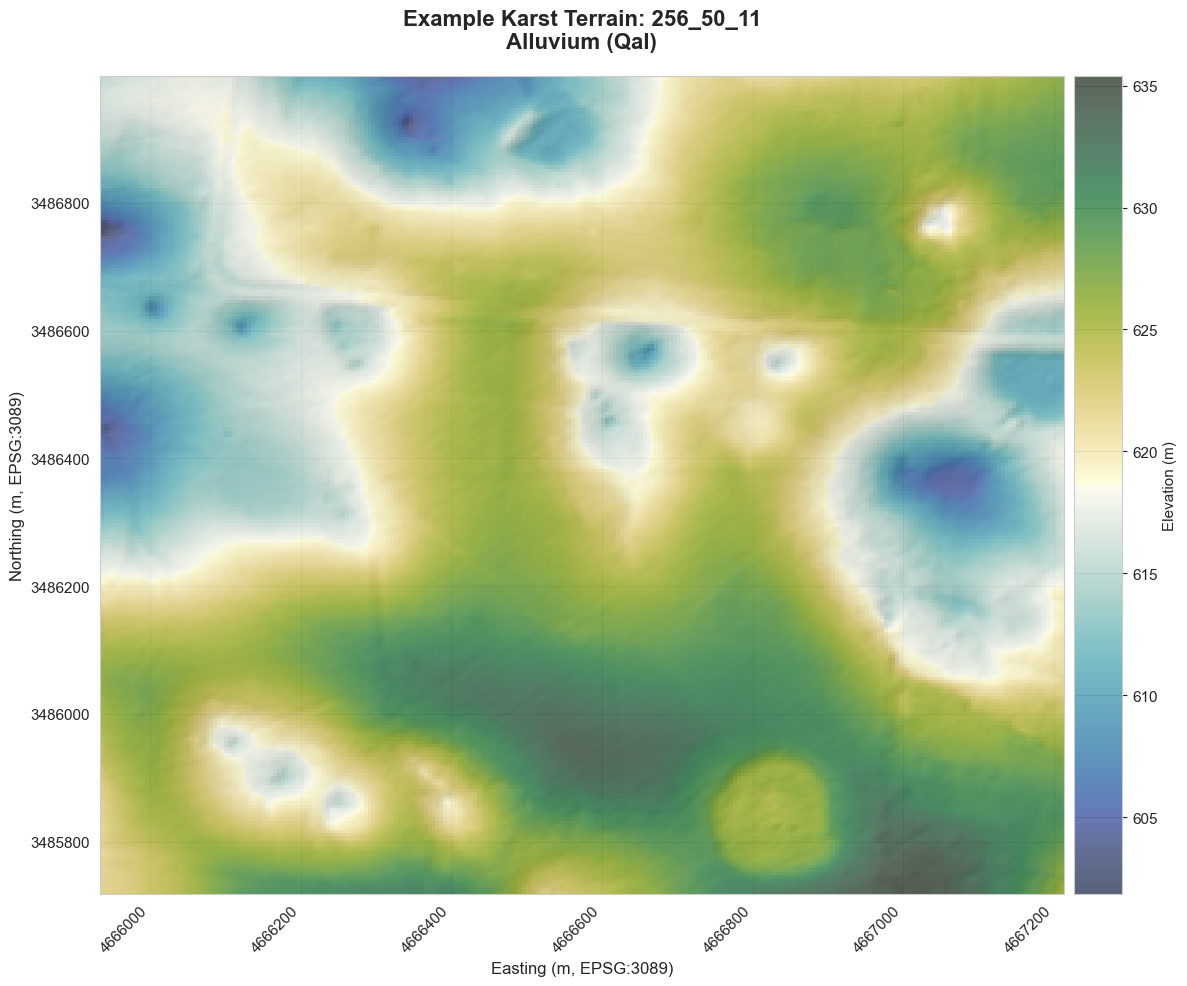

In [28]:
print("Creating contextual map...")

fig, ax = plt.subplots(figsize=(12, 10))

plot_dem_with_hillshade(
    dem_xr, 
    ax, 
    cmap=cmocean.cm.delta, 
    alpha_hillshade=0.5,
    add_colorbar=True
)

# Format axes labels based on CRS
format_coords_labels(ax, dem_xr.rio.crs)

# Set title with metadata
ax.set_title(
    f'Example Karst Terrain: {EXEMPLAR_TILE_ID}\n{class_name}',
    fontsize=16, fontweight='bold', pad=20
)

# Format tick labels
ax.ticklabel_format(style='plain', useOffset=False)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"{EXEMPLAR_TILE_ID}_contextual_map.png", 
            dpi=300, bbox_inches='tight', facecolor='white')
print(f"Saved: {EXEMPLAR_TILE_ID}_contextual_map.png")
plt.show()

### Visual 2: The Task Plot (SHAPE → LABELS)

Creating Task Plot...


C:\Users\mkerr\AppData\Local\Temp\ipykernel_2320\2601658028.py:28: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  arrow = mpatches.FancyArrow(


✓ Saved: 256_50_11_task_plot.png


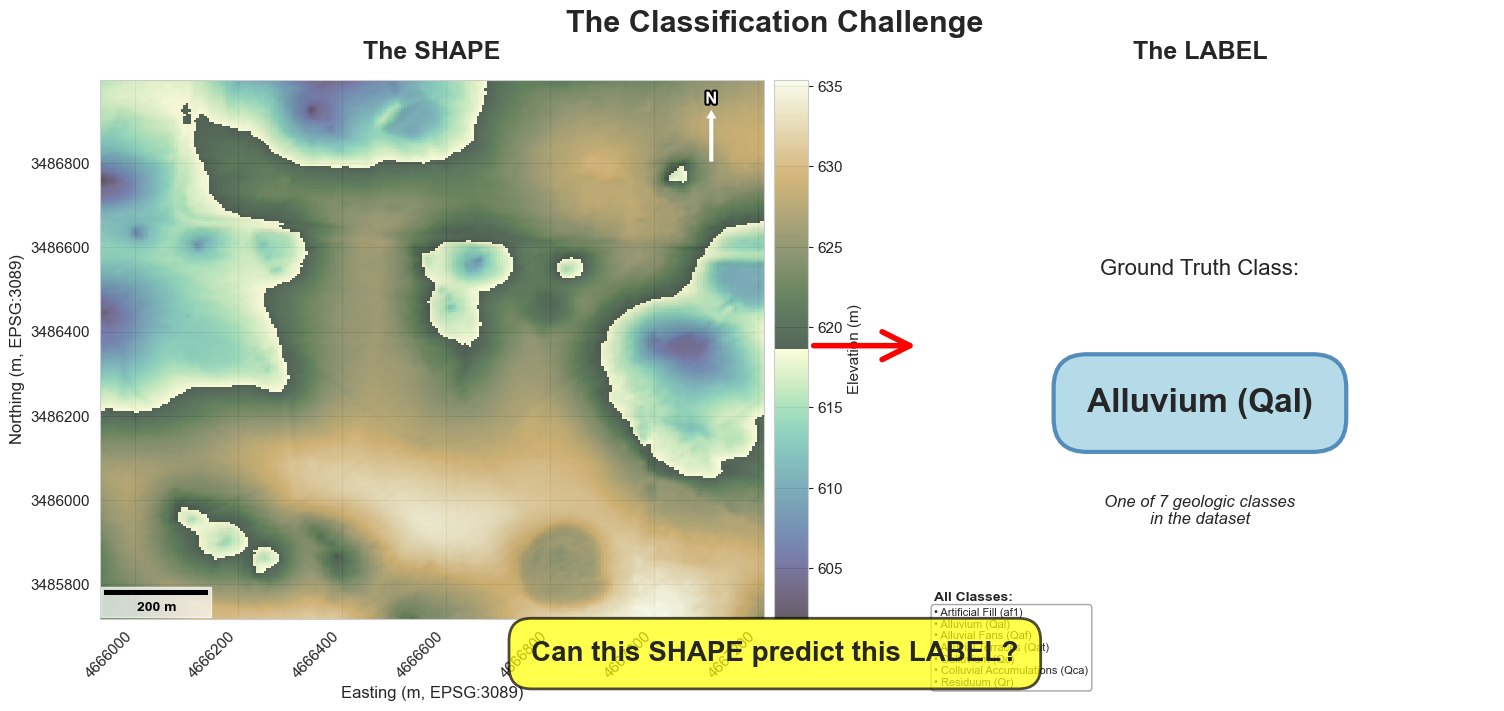

In [11]:
print("Creating Task Plot...")

fig = plt.figure(figsize=(18, 7))
gs = fig.add_gridspec(1, 2, width_ratios=[1.2, 1], wspace=0.15)
ax_map = fig.add_subplot(gs[0])
ax_labels = fig.add_subplot(gs[1])

# LEFT PANEL: Map
plot_dem_with_hillshade(
    dem_xr,
    ax_map,
    cmap=cmap_dem,
    alpha_dem=0.7,
    alpha_hillshade=0.3,
    add_colorbar=True
)

# Add cartographic elements
add_north_arrow(ax_map, x=0.92, y=0.93, arrow_length=0.08)
add_scalebar(ax_map, dem_xr.rio.crs, location='lower left', length_fraction=0.2)

# Format labels
format_coords_labels(ax_map, dem_xr.rio.crs)
ax_map.set_title('The SHAPE', fontsize=18, fontweight='bold', pad=15)
ax_map.ticklabel_format(style='plain', useOffset=False)
plt.setp(ax_map.get_xticklabels(), rotation=45, ha='right')

# RIGHT PANEL: Class Label (Simple and Clear)
ax_labels.axis('off')  # Turn off axes for clean presentation

# Show the actual class prominently
ax_labels.text(0.5, 0.65, 'Ground Truth Class:',
              ha='center', va='center', fontsize=16, transform=ax_labels.transAxes)

# Show class name in a box
ax_labels.text(0.5, 0.4, class_name,
              ha='center', va='center', fontsize=24, fontweight='bold',
              transform=ax_labels.transAxes,
              bbox=dict(boxstyle='round,pad=1.0', facecolor='lightblue', 
                       edgecolor='steelblue', linewidth=3, alpha=0.9))

# Add context about the dataset
total_classes = len(CLASS_NAMES)
ax_labels.text(0.5, 0.2, f'One of {total_classes} geologic classes\nin the dataset',
              ha='center', va='center', fontsize=12, style='italic',
              transform=ax_labels.transAxes)

# Optional: Show all classes as a legend
class_list_y = 0.05
class_text = '\n'.join([f"• {name}" for name in CLASS_NAMES])
ax_labels.text(0.05, class_list_y, 'All Classes:',
              ha='left', va='top', fontsize=10, fontweight='bold',
              transform=ax_labels.transAxes)
ax_labels.text(0.05, class_list_y - 0.03, class_text,
              ha='left', va='top', fontsize=8,
              transform=ax_labels.transAxes,
              bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='gray'))

ax_labels.set_title('The LABEL', fontsize=18, fontweight='bold', pad=15)

# Central question
fig.text(0.5, 0.05, 'Can this SHAPE predict this LABEL?',
        ha='center', fontsize=20, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.8', facecolor='yellow', alpha=0.7, edgecolor='black', linewidth=2))

# Arrow
arrow = FancyArrowPatch((0.52, 0.5), (0.58, 0.5), transform=fig.transFigure,
                       arrowstyle='->', mutation_scale=50, linewidth=4, color='red', zorder=10)
fig.patches.append(arrow)

plt.suptitle('The Classification Challenge', fontsize=22, fontweight='bold', y=0.98)
plt.savefig(OUTPUT_DIR / f"{EXEMPLAR_TILE_ID}_task_plot.png", 
            dpi=300, bbox_inches='tight', facecolor='white')
print(f"✓ Saved: {EXEMPLAR_TILE_ID}_task_plot.png")
plt.show()

---

## Phase 3: Act II - The Method

**Goal:** Intuitively explain Persistent Homology and compare all feature representations

### Step 1: Compute Persistence Diagram

In [12]:
print("Computing Persistent Homology...")
start_time = time.time()

# Prepare DEM for persistence homology computation
dem_for_ph = np.copy(dem_array)
dem_for_ph[~np.isfinite(dem_for_ph)] = np.nanmin(dem_for_ph) if np.any(np.isfinite(dem_for_ph)) else 0.0
dem_for_ph = dem_for_ph.astype(np.float32)

# Compute persistence homology
pd_result = cripser.computePH(dem_for_ph, maxdim=1)
compute_time = time.time() - start_time

print(f"  Raw PD result type: {type(pd_result)}, shape: {pd_result.shape if hasattr(pd_result, 'shape') else 'N/A'}")
print(f"  First few entries:\n{pd_result[:5] if len(pd_result) > 0 else 'empty'}")

# Parse results into structured format
# Cripser returns: [dim, birth, death, ...other columns...]
if isinstance(pd_result, list):
    # Convert list to structured array
    pd_array = np.array(pd_result, dtype=[('birth', 'f4'), ('death', 'f4'), ('dim', 'i4')])
elif pd_result.dtype.names is not None:
    # Already a structured array
    pd_array = pd_result
else:
    # Regular array - extract the correct columns
    # Based on the output, cripser format appears to be: [dim, birth, death, ...]
    if pd_result.shape[1] >= 3:
        pd_array = np.empty(len(pd_result), dtype=[('birth', 'f4'), ('death', 'f4'), ('dim', 'i4')])
        pd_array['dim'] = pd_result[:, 0].astype(np.int32)   # Column 0 is dimension
        pd_array['birth'] = pd_result[:, 1]  # Column 1 is birth elevation
        
        # Handle potential inf values in death column (suppress overflow warning)
        with np.errstate(over='ignore'):
            pd_array['death'] = pd_result[:, 2]  # Column 2 is death elevation
    else:
        raise ValueError(f"Unexpected pd_result shape: {pd_result.shape}")

print(f"  Total features before filtering: {len(pd_array)}")
print(f"  Birth range: [{pd_array['birth'].min():.2f}, {pd_array['birth'].max():.2f}]")
print(f"  Death range: [{pd_array['death'][np.isfinite(pd_array['death'])].min():.2f}, {pd_array['death'].max():.2f}]")
print(f"  Dimensions found: {np.unique(pd_array['dim'])}")

# Filter for valid features
# Keep features where death is finite (inf means the feature never dies)
valid_mask = (
    (pd_array['dim'] >= 0) &
    (pd_array['dim'] <= 1) &  # Only H0 and H1
    np.isfinite(pd_array['birth']) &
    (np.isfinite(pd_array['death']) | np.isinf(pd_array['death']))  # Keep infinite deaths
)

# For infinite deaths, replace with max elevation
pd_array_clean = pd_array[valid_mask].copy()
inf_mask = np.isinf(pd_array_clean['death'])
if inf_mask.any():
    pd_array_clean['death'][inf_mask] = np.nanmax(dem_array) + 1.0  # Slightly above max
    print(f"  Replaced {inf_mask.sum()} infinite death values")

# Now filter persistence (death > birth)
persistence_mask = pd_array_clean['death'] > pd_array_clean['birth']
pd_array = pd_array_clean[persistence_mask]

# Separate by homological dimension
h0_pairs = pd_array[pd_array['dim'] == 0]
h1_pairs = pd_array[pd_array['dim'] == 1]

# Get elevation range for plotting
if len(pd_array) > 0:
    max_val = max(pd_array['death'].max(), pd_array['birth'].max())
    min_val = min(pd_array['death'].min(), pd_array['birth'].min())
else:
    # Use DEM range as fallback
    max_val = np.nanmax(dem_array)
    min_val = np.nanmin(dem_array)

print(f"✓ Computed PH in {compute_time:.3f} seconds")
print(f"  H0 (components): {len(h0_pairs)} features")
print(f"  H1 (loops): {len(h1_pairs)} features")
if len(pd_array) > 0:
    persistence_vals = pd_array['death'] - pd_array['birth']
    print(f"  Persistence range: [{persistence_vals.min():.3f}, {persistence_vals.max():.3f}]")

Computing Persistent Homology...
  Raw PD result type: <class 'numpy.ndarray'>, shape: (593, 9)
  First few entries:
[[  0.         603.56213379 603.58026123 110.           1.
    0.         110.           2.           0.        ]
 [  0.         604.06732178 604.15435791 113.           2.
    0.         112.           2.           0.        ]
 [  0.         604.65509033 604.67785645 127.         231.
    0.         127.         230.           0.        ]
 [  0.         603.88391113 605.77038574   0.          87.
    0.           7.          85.           0.        ]
 [  0.         606.10717773 606.1583252  125.         215.
    0.         124.         215.           0.        ]]
  Total features before filtering: 593
  Birth range: [601.86, 635.33]
  Death range: [603.58, inf]
  Dimensions found: [0 1]
  Replaced 1 infinite death values
✓ Computed PH in 0.065 seconds
  H0 (components): 350 features
  H1 (loops): 243 features
  Persistence range: [0.000, 34.529]


### Visualize Persistence Diagram

✓ Saved: 256_50_11_persistence_diagram.png


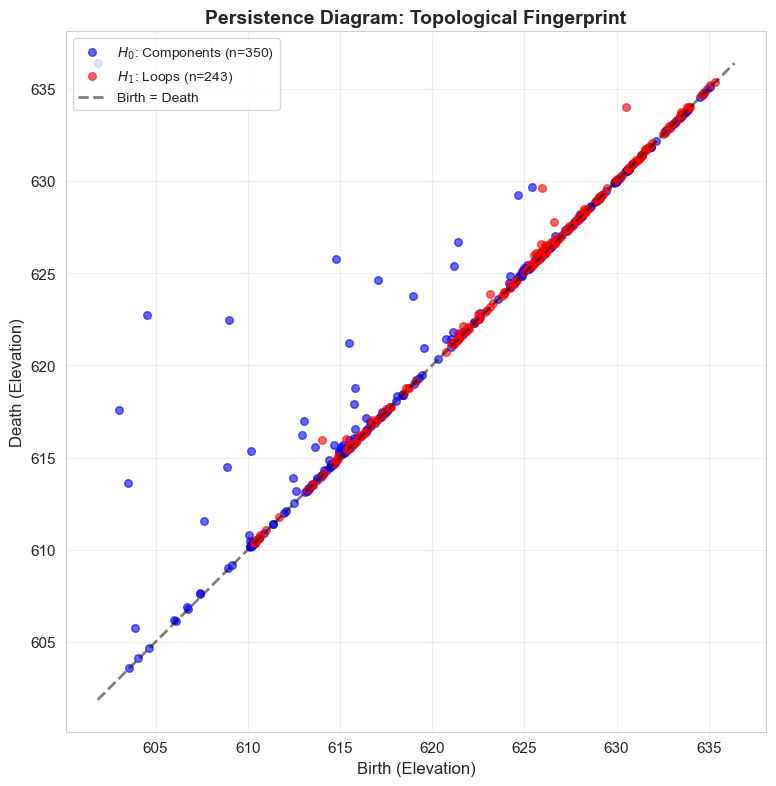

In [13]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(h0_pairs['birth'], h0_pairs['death'], 
          alpha=0.6, s=30, c='blue', label=f'$H_0$: Components (n={len(h0_pairs)})')
ax.scatter(h1_pairs['birth'], h1_pairs['death'],
          alpha=0.6, s=30, c='red', label=f'$H_1$: Loops (n={len(h1_pairs)})')
ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, linewidth=2, label='Birth = Death')

ax.set_xlabel('Birth (Elevation)', fontsize=12)
ax.set_ylabel('Death (Elevation)', fontsize=12)
ax.set_title('Persistence Diagram: Topological Fingerprint', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"{EXEMPLAR_TILE_ID}_persistence_diagram.png", dpi=300, bbox_inches='tight')
print(f"✓ Saved: {EXEMPLAR_TILE_ID}_persistence_diagram.png")
plt.show()

### Visual 3: Filtration Animation

**Note:** This creates an animated GIF showing the "rising water" filtration process.

In [14]:
print("Creating filtration animation...")

fig, (ax_map, ax_pd) = plt.subplots(1, 2, figsize=(16, 7))

# LEFT: DEM with water - using improved visualization
cmap_water = cmocean.cm.haline if cmocean else plt.cm.Blues

# Plot base terrain with hillshade
ax_map.imshow(hillshade, cmap='gray', alpha=0.4, extent=[0, dem_array.shape[1], 0, dem_array.shape[0]])
ax_map.imshow(dem_array, cmap=plt.cm.terrain, alpha=0.5, extent=[0, dem_array.shape[1], 0, dem_array.shape[0]])

# Initialize water layer
water_data = np.full_like(dem_array, np.nan)
im_water = ax_map.imshow(water_data, cmap=cmap_water, alpha=0.7, vmin=0, vmax=1,
                         extent=[0, dem_array.shape[1], 0, dem_array.shape[0]], zorder=10)

ax_map.set_title('Filtration: Rising Water Level', fontsize=14, fontweight='bold')
ax_map.set_xlabel('X (pixels)', fontsize=11)
ax_map.set_ylabel('Y (pixels)', fontsize=11)
ax_map.set_aspect('equal')

# Elevation text
text_elev = ax_map.text(0.02, 0.98, '', transform=ax_map.transAxes, 
                        fontsize=14, fontweight='bold', va='top',
                        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='black', linewidth=2))

# RIGHT: Persistence diagram
ax_pd.scatter(h0_pairs['birth'], h0_pairs['death'], alpha=0.3, s=20, c='blue', label='$H_0$')
ax_pd.scatter(h1_pairs['birth'], h1_pairs['death'], alpha=0.3, s=20, c='red', label='$H_1$')
line_current = ax_pd.axhline(y=min_val, color='green', linestyle='--', linewidth=3, label='Current Level', zorder=10)
ax_pd.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, linewidth=2)
ax_pd.set_xlabel('Birth (Elevation, m)', fontsize=12)
ax_pd.set_ylabel('Death (Elevation, m)', fontsize=12)
ax_pd.set_title('Active Topological Features', fontsize=14, fontweight='bold')
ax_pd.legend(loc='upper left', fontsize=10)
ax_pd.grid(True, alpha=0.3)
ax_pd.set_aspect('equal')

plt.tight_layout()

# Animation function
n_frames = 60
elevation_range = np.linspace(np.nanmin(dem_array), np.nanmax(dem_array), n_frames)

def animate(frame):
    current_elev = elevation_range[frame]
    water_mask = dem_array <= current_elev
    im_water.set_data(np.where(water_mask, 1.0, np.nan))
    text_elev.set_text(f'Water Level: {current_elev:.2f} m')
    line_current.set_ydata([current_elev, current_elev])
    return im_water, text_elev, line_current

anim = FuncAnimation(fig, animate, frames=n_frames, interval=100, blit=True)

output_path = OUTPUT_DIR / f"{EXEMPLAR_TILE_ID}_filtration_animation.gif"
writer = PillowWriter(fps=10)

# Progress bar for animation save
print("  Saving animation...")
pbar = tqdm(total=n_frames, desc="  Rendering frames", unit="frame", leave=False)

def progress_callback(frame_number, total_frames):
    pbar.update(1)

anim.save(output_path, writer=writer, progress_callback=progress_callback)
pbar.close()

print(f"✓ Saved: {EXEMPLAR_TILE_ID}_filtration_animation.gif")
plt.close()

Creating filtration animation...
  Saving animation...


  Rendering frames:   0%|          | 0/60 [00:00<?, ?frame/s]

✓ Saved: 256_50_11_filtration_animation.gif


### Visual 3b: Directional PH Animation

**Note:** This creates an animated GIF showing how directional biases capture anisotropic terrain features.

In [15]:
# ----------------------------------------------------------------------
# NOTE: This block assumes all necessary imports (numpy as np,
# matplotlib.pyplot as plt, matplotlib.patches as mpatches,
# matplotlib.animation.FuncAnimation, PIL.ImageWrite.PillowWriter,
# tqdm.tqdm, cripser) and variables (dem_array, generate_hillshade,
# cmap_dem, OUTPUT_DIR, EXEMPLAR_TILE_ID, os) are defined in
# preceding cells.
# ----------------------------------------------------------------------

print("Creating directional PH filtration animation...")

# Prepare normalized DEM (as done in compute_ph_directional)
dem_clean = np.copy(dem_array)
# Handle NaNs/Infs by setting them to the minimum valid elevation
dem_clean[~np.isfinite(dem_clean)] = np.nanmin(dem_clean) if np.any(np.isfinite(dem_clean)) else 0.0

# Normalize to [0, 1]
tile_min, tile_max = dem_clean.min(), dem_clean.max()
tile_range = tile_max - tile_min
tile_normalized = (dem_clean - tile_min) / tile_range if tile_range > 0 else dem_clean - tile_min

# Create coordinate grids for directional gradients
rows, cols = tile_normalized.shape
# Standardize coordinates to roughly [-1, 1] for consistent gradient scale
y_coords = np.linspace(-1, 1, rows)[:, np.newaxis]  # Vertical axis (y = sin(angle))
x_coords = np.linspace(-1, 1, cols)[np.newaxis, :]  # Horizontal axis (x = cos(angle))

# Define 8 directions (N, NE, E, SE, S, SW, W, NW)
n_directions = 8
angles = np.linspace(0, 2 * np.pi, n_directions, endpoint=False)
# Adjust direction names to match angular order: E(0), NE, N(pi/2), NW, W(pi), SW, S(3pi/2), SE
direction_names = ['E', 'NE', 'N', 'NW', 'W', 'SW', 'S', 'SE']
gradient_strength = 0.1

# --- Determine universal min/max filtration range (for PD plot) ---
# The total range of the Biased DEMs is approximately [-0.1, 1.1]
FILTRATION_MIN = 0.0 + gradient_strength * (-1.0)
FILTRATION_MAX = 1.0 + gradient_strength * (1.0)
# The range of the raw directional gradient (for map sweep) is [-1, 1]
GRADIENT_MIN = -1.0
GRADIENT_MAX = 1.0

# --- Visualization Constants (Anchored to Mean Elevation) ---
# Calculate the mean of the normalized DEM for focusing the visualization
NORMALIZED_DEM_MEAN = tile_normalized[np.isfinite(tile_normalized)].mean()
VISUALIZATION_BAND_WIDTH = 0.25  # Increased band width for better visibility
VIS_LOWER_BOUND = NORMALIZED_DEM_MEAN - VISUALIZATION_BAND_WIDTH / 2
VIS_UPPER_BOUND = NORMALIZED_DEM_MEAN + VISUALIZATION_BAND_WIDTH / 2


# Precompute all directionally-biased DEMs and their persistence diagrams
print("  Precomputing directional filtrations...")
biased_dems = []
directional_gradients = []  # Store pure gradients (the sweeping plane)
all_pd_diagrams = []

# Progress bar for precomputation
for angle in tqdm(angles, desc="  Computing directions", unit="dir", leave=False):
    # Create directional gradient (this defines the flow direction)
    # The mathematical height function h_v(x) = v.x, where v = (cos(angle), sin(angle))
    # FIX: Invert the y-component (sin) to match matplotlib's inverted y-axis
    # A "North" angle (pi/2) should have a gradient increasing "up" (lower y-index)
    # -y_coords * sin(pi/2) = -y_coords. -y_coords goes from +1 (top) to -1 (bottom).
    # The sweep h <= threshold will start at the bottom (h=-1) and move up.
    directional_gradient = x_coords * np.cos(angle) - y_coords * np.sin(angle)
    directional_gradients.append(directional_gradient)

    # Add directional bias to normalized elevation
    # NOTE: The persistence diagram calculation relies on this BIAS (or "tilt")
    biased_tile_norm = tile_normalized + gradient_strength * directional_gradient
    biased_dems.append(biased_tile_norm)

    # Compute PH for this direction
    try:
        # cripser requires float32
        pd_dir = cripser.computePH(biased_tile_norm.astype(np.float32), maxdim=1)

        # --- Persistence Diagram Parsing ---
        if pd_dir.shape[1] >= 3:
            pd_array_dir = np.empty(len(pd_dir), dtype=[('birth', 'f4'), ('death', 'f4'), ('dim', 'i4')])
            pd_array_dir['dim'] = pd_dir[:, 0].astype(np.int32)
            pd_array_dir['birth'] = pd_dir[:, 1]
            with np.errstate(over='ignore'):
                pd_array_dir['death'] = pd_dir[:, 2]

            # Filter for valid features
            valid_mask = (
                (pd_array_dir['dim'] >= 0) &
                (pd_array_dir['dim'] <= 1) &
                np.isfinite(pd_array_dir['birth']) &
                (np.isfinite(pd_array_dir['death']) | np.isinf(pd_array_dir['death']))
            )
            pd_array_dir_clean = pd_array_dir[valid_mask].copy()

            # Replace infinite deaths (using the universal max filtration value + epsilon)
            inf_mask = np.isinf(pd_array_dir_clean['death'])
            if inf_mask.any():
                pd_array_dir_clean['death'][inf_mask] = FILTRATION_MAX + 0.01

            # Filter for positive persistence
            persistence_mask = pd_array_dir_clean['death'] > pd_array_dir_clean['birth']
            pd_array_dir_final = pd_array_dir_clean[persistence_mask]

            all_pd_diagrams.append(pd_array_dir_final)
        else:
            all_pd_diagrams.append(np.array([], dtype=[('birth', 'f4'), ('death', 'f4'), ('dim', 'i4')]))
    except Exception as e:
        print(f"Error computing PH for angle {angle}: {e}")
        all_pd_diagrams.append(np.array([], dtype=[('birth', 'f4'), ('death', 'f4'), ('dim', 'i4')]))

print(f"  ✓ Computed filtrations for {n_directions} directions")

# Create figure with 2 panels
# FIX: Increased figure size slightly to prevent arrow/text cutoff
fig, (ax_map, ax_pd) = plt.subplots(1, 2, figsize=(18, 8))

# --- LEFT: DEM with directional sweeping plane ---

# 1. Plot base terrain (fixed)
# Assuming generate_hillshade is available from a previous cell/import
base_hillshade = generate_hillshade(dem_clean, azimuth=315, altitude=45)
im_hillshade = ax_map.imshow(base_hillshade, cmap='gray', alpha=0.4, extent=[0, cols, 0, rows], zorder=1)
# Assuming cmap_dem is available. The base terrain is kept transparent enough to see the hillshade.
im_terrain = ax_map.imshow(tile_normalized, cmap=cmap_dem, alpha=0.3, extent=[0, cols, 0, rows], zorder=2)

# 2. Initialize directional sweep layer
# We use the 'viridis' colormap for the sweep
# --- FIX: Replaced deprecated plt.cm.get_cmap() with plt.colormaps[] ---
cmap_flow = plt.colormaps['viridis']
water_data = np.full_like(tile_normalized, np.nan)
im_water = ax_map.imshow(water_data, cmap=cmap_flow, alpha=0.7,
                         vmin=GRADIENT_MIN, vmax=GRADIENT_MAX,
                         extent=[0, cols, 0, rows], zorder=10)

# Add a colorbar for the sweeping plane visualization
cbar = fig.colorbar(im_water, ax=ax_map, fraction=0.046, pad=0.04)
cbar.set_label('Directional Gradient Value (Sweeping Plane)')


ax_map.set_title('Directional Sweeping Plane Filtered by Elevation Band', fontsize=14, fontweight='bold')
ax_map.set_xlabel('X (pixels)', fontsize=11)
ax_map.set_ylabel('Y (pixels)', fontsize=11)
ax_map.set_aspect('equal')

# Direction arrow
arrow_length = 60
arrow_center_x, arrow_center_y = cols * 0.85, rows * 0.15
# FIX: Center the arrow at the specified point, rather than starting the tail there.
# This prevents the arrow from being drawn off-canvas when pointing up/left.
# Also, apply the y-inversion (-np.sin) to match the gradient direction.
angle0 = angles[0]
dx0 = arrow_length * np.cos(angle0)
# *** MAJOR FIX HERE ***
# The 'extent=[0, cols, 0, rows]' in imshow already flips the y-axis
# so that y=0 is at the bottom. A positive dy now correctly points UP.
# The original '-np.sin(angle0)' was an incorrect double-inversion.
dy0 = arrow_length * np.sin(angle0)
x_tail0 = arrow_center_x - dx0 / 2
y_tail0 = arrow_center_y - dy0 / 2

arrow_container = [mpatches.FancyArrow(
    x_tail0, y_tail0, dx0, dy0,  # Start at tail, draw for (dx, dy)
    width=8, head_width=20, head_length=15,
    facecolor='red', edgecolor='black', linewidth=2, alpha=0.9, zorder=15
)]
ax_map.add_patch(arrow_container[0])

# Text annotations
text_dir = ax_map.text(0.02, 0.98, '', transform=ax_map.transAxes,
                       fontsize=14, fontweight='bold', va='top',
                       bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                                 alpha=0.9, edgecolor='red', linewidth=2))

# FIX: Renamed to be more general
text_elev = ax_map.text(0.02, 0.88, '', transform=ax_map.transAxes,
                        fontsize=12, fontweight='bold', va='top',
                        bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                                  alpha=0.9, edgecolor='black', linewidth=2))

# --- RIGHT: Persistence diagram ---
# FIX: Updated titles and labels to use clearer "Directional Filtration" terminology
ax_pd.set_xlabel('Birth (Directional Filtration Value)', fontsize=12)
ax_pd.set_ylabel('Death (Directional Filtration Value)', fontsize=12)
ax_pd.set_title('Directional Persistence Diagram', fontsize=14, fontweight='bold')
ax_pd.grid(True, alpha=0.3)
ax_pd.set_aspect('equal')
# Set PD limits to the range of the filtration function f_v(x)
ax_pd.set_xlim(FILTRATION_MIN - 0.05, FILTRATION_MAX + 0.05)
ax_pd.set_ylim(FILTRATION_MIN - 0.05, FILTRATION_MAX + 0.05)


# These will be updated in animation
scatter_h0 = ax_pd.scatter([], [], alpha=0.6, s=20, c='blue', label='$H_0$', zorder=3)
scatter_h1 = ax_pd.scatter([], [], alpha=0.6, s=20, c='red', label='$H_1$', zorder=3)
# The green line tracks the threshold value in the *PD space* (Biased DEM space)
line_current = ax_pd.axhline(y=0, color='green', linestyle='--', linewidth=3, label='Filtration Threshold', zorder=10)
line_diagonal = ax_pd.plot([FILTRATION_MIN, FILTRATION_MAX], [FILTRATION_MIN, FILTRATION_MAX], 'k--', alpha=0.5, linewidth=2, zorder=1)[0]
ax_pd.legend(loc='upper left', fontsize=10)

plt.tight_layout()

# Animation parameters
n_frames_per_dir = 25  # Frames for smoother sweeping
total_frames = n_directions * n_frames_per_dir

print(f"  Creating animation with {total_frames} frames...")

# Animation function
def animate(frame):
    # Determine which direction we're in
    direction_idx = frame // n_frames_per_dir
    frame_in_dir = frame % n_frames_per_dir

    # Get current biased DEM (for PD update) and raw gradient (for map update)
    biased_dem_norm = biased_dems[direction_idx]
    directional_gradient = directional_gradients[direction_idx]
    
    # 1. Calculate the current threshold for the FILTRATION
    # This sweep is used to track features on the Persistence Diagram (PD)
    current_progress = frame_in_dir / (n_frames_per_dir - 1) if n_frames_per_dir > 1 else 1.0
    filtration_range = FILTRATION_MAX - FILTRATION_MIN
    water_threshold_norm = FILTRATION_MIN + current_progress * filtration_range

    # 2. Calculate the threshold for the VISUAL SWEEP (Raw Gradient Space)
    gradient_range = GRADIENT_MAX - GRADIENT_MIN
    sweep_threshold = GRADIENT_MIN + current_progress * gradient_range

    # --- Update Map (Visualizing the sweeping plane + elevation band) ---
    
    # 1. Sweeping Plane Mask: based ONLY on the RAW GRADIENT (the flashlight effect)
    sweep_mask = directional_gradient <= sweep_threshold

    # 2. Elevation Filter: Only show the water where the *original* normalized elevation is within the defined band
    elevation_filter = (tile_normalized >= VIS_LOWER_BOUND) & \
                       (tile_normalized <= VIS_UPPER_BOUND)

    # 3. Combine Masks: Flooded area is where the sweep is active AND the elevation is in the band.
    combined_mask = sweep_mask & elevation_filter

    # For the water display, use the RAW GRADIENT values only where the combined mask is active.
    water_display = np.where(combined_mask, directional_gradient, np.nan)
    im_water.set_data(water_display)
    
    # --- Update Arrow ---
    if frame_in_dir == 0:
        # FIX: Apply centered arrow logic, matching the gradient direction
        # (angle) and inverted y-axis (-np.sin)
        arrow_container[0].remove()
        
        angle = angles[direction_idx]
        dx = arrow_length * np.cos(angle)
        # *** MAJOR FIX HERE ***
        # Same fix as initialization. The axes are already flipped.
        # We need a positive dy for 'North' (sin(pi/2) = +1).
        dy = arrow_length * np.sin(angle)
        x_tail = arrow_center_x - dx / 2
        y_tail = arrow_center_y - dy / 2
        
        new_arrow = mpatches.FancyArrow(
            x_tail, y_tail, dx, dy,
            width=8, head_width=20, head_length=15,
            facecolor='red', edgecolor='black', linewidth=2, alpha=0.9, zorder=15
        )
        ax_map.add_patch(new_arrow)
        arrow_container[0] = new_arrow

    # --- Update Text ---
    text_dir.set_text(f'Flow Direction: {direction_names[direction_idx]}')
    # FIX: Updated text to be clearer
    text_elev.set_text(f'Filtration Level: {water_threshold_norm:.3f} / {FILTRATION_MAX:.3f}')

    # --- Update Persistence Diagram ---
    pd_current = all_pd_diagrams[direction_idx]
    if pd_current.size > 0:
        active_mask = (pd_current['birth'] <= water_threshold_norm) & (pd_current['death'] > water_threshold_norm)
        active_features = pd_current[active_mask]

        h0_active = active_features[active_features['dim'] == 0]
        h1_active = active_features[active_features['dim'] == 1]

        scatter_h0.set_offsets(np.column_stack([h0_active['birth'], h0_active['death']]))
        scatter_h1.set_offsets(np.column_stack([h1_active['birth'], h1_active['death']]))
        
        line_current.set_ydata([water_threshold_norm, water_threshold_norm])
        line_current.set_xdata(ax_pd.get_xlim()) 

    else:
        scatter_h0.set_offsets(np.empty((0, 2)))
        scatter_h1.set_offsets(np.empty((0, 2)))
        line_current.set_ydata([water_threshold_norm, water_threshold_norm])
        line_current.set_xdata(ax_pd.get_xlim())

    # Return elements that changed
    # FIX: Simplified return list to only dynamically changing objects to avoid IndexError
    return [im_water, arrow_container[0], text_dir, text_elev, scatter_h0, scatter_h1, line_current]

# --- Use blit=False ---
# blit=True is faster but notoriously buggy with patches being added/removed
# (like our arrow). blit=False is safer and more reliable here.
anim = FuncAnimation(fig, animate, frames=total_frames, interval=100, blit=False)

output_path = os.path.join(OUTPUT_DIR, f"{EXEMPLAR_TILE_ID}_directional_ph_animation.gif")
writer = PillowWriter(fps=10)

# Progress bar for animation save
print("  Saving animation...")
pbar = tqdm(total=total_frames, desc="  Rendering frames", unit="frame", leave=False)

def progress_callback(frame_number, total_frames):
    pbar.update(1)

anim.save(output_path, writer=writer, progress_callback=progress_callback)
pbar.close()

print(f"✓ Saved: {EXEMPLAR_TILE_ID}_directional_ph_animation.gif ({total_frames} frames)")
plt.close()

Creating directional PH filtration animation...
  Precomputing directional filtrations...


  Computing directions:   0%|          | 0/8 [00:00<?, ?dir/s]

  ✓ Computed filtrations for 8 directions
  Creating animation with 200 frames...
  Saving animation...


  Rendering frames:   0%|          | 0/200 [00:00<?, ?frame/s]

✓ Saved: 256_50_11_directional_ph_animation.gif (200 frames)


### Visual 4-5

In [16]:
# Prepare PD in giotto-tda format
# Ensure we have valid data
if len(pd_array) > 0:
    pd_gtda = np.column_stack([pd_array['birth'], pd_array['death'], pd_array['dim'].astype(np.float64)])
    pd_gtda = pd_gtda[np.newaxis, :, :]
else:
    # Create empty persistence diagram with proper shape if no features
    print("  Warning: No valid persistence features found. Creating minimal diagram.")
    # Create a single dummy feature that won't affect computations
    pd_gtda = np.array([[[min_val, min_val + 0.001, 0]]])

# Compute different representations
print("  Computing ECC...")
betti_for_ecc = BettiCurve(n_bins=50, n_jobs=1).fit_transform(pd_gtda)
ecc_curve = betti_for_ecc[0].sum(axis=1)

print("  Computing Betti Curves...")
betti_curves = BettiCurve(n_bins=100, n_jobs=1).fit_transform(pd_gtda)[0]

print("  Computing Landscapes...")
landscapes = PersistenceLandscape(n_layers=5, n_bins=100, n_jobs=1).fit_transform(pd_gtda)[0]

print("  Computing Persistence Images...")
persimages = PersistenceImage(n_bins=50, n_jobs=1).fit_transform(pd_gtda)[0]

print("✓ All representations computed")

  Computing ECC...
  Computing Betti Curves...
  Computing Landscapes...
  Computing Persistence Images...
✓ All representations computed


✓ Saved: 256_50_11_feature_rosetta_stone.png


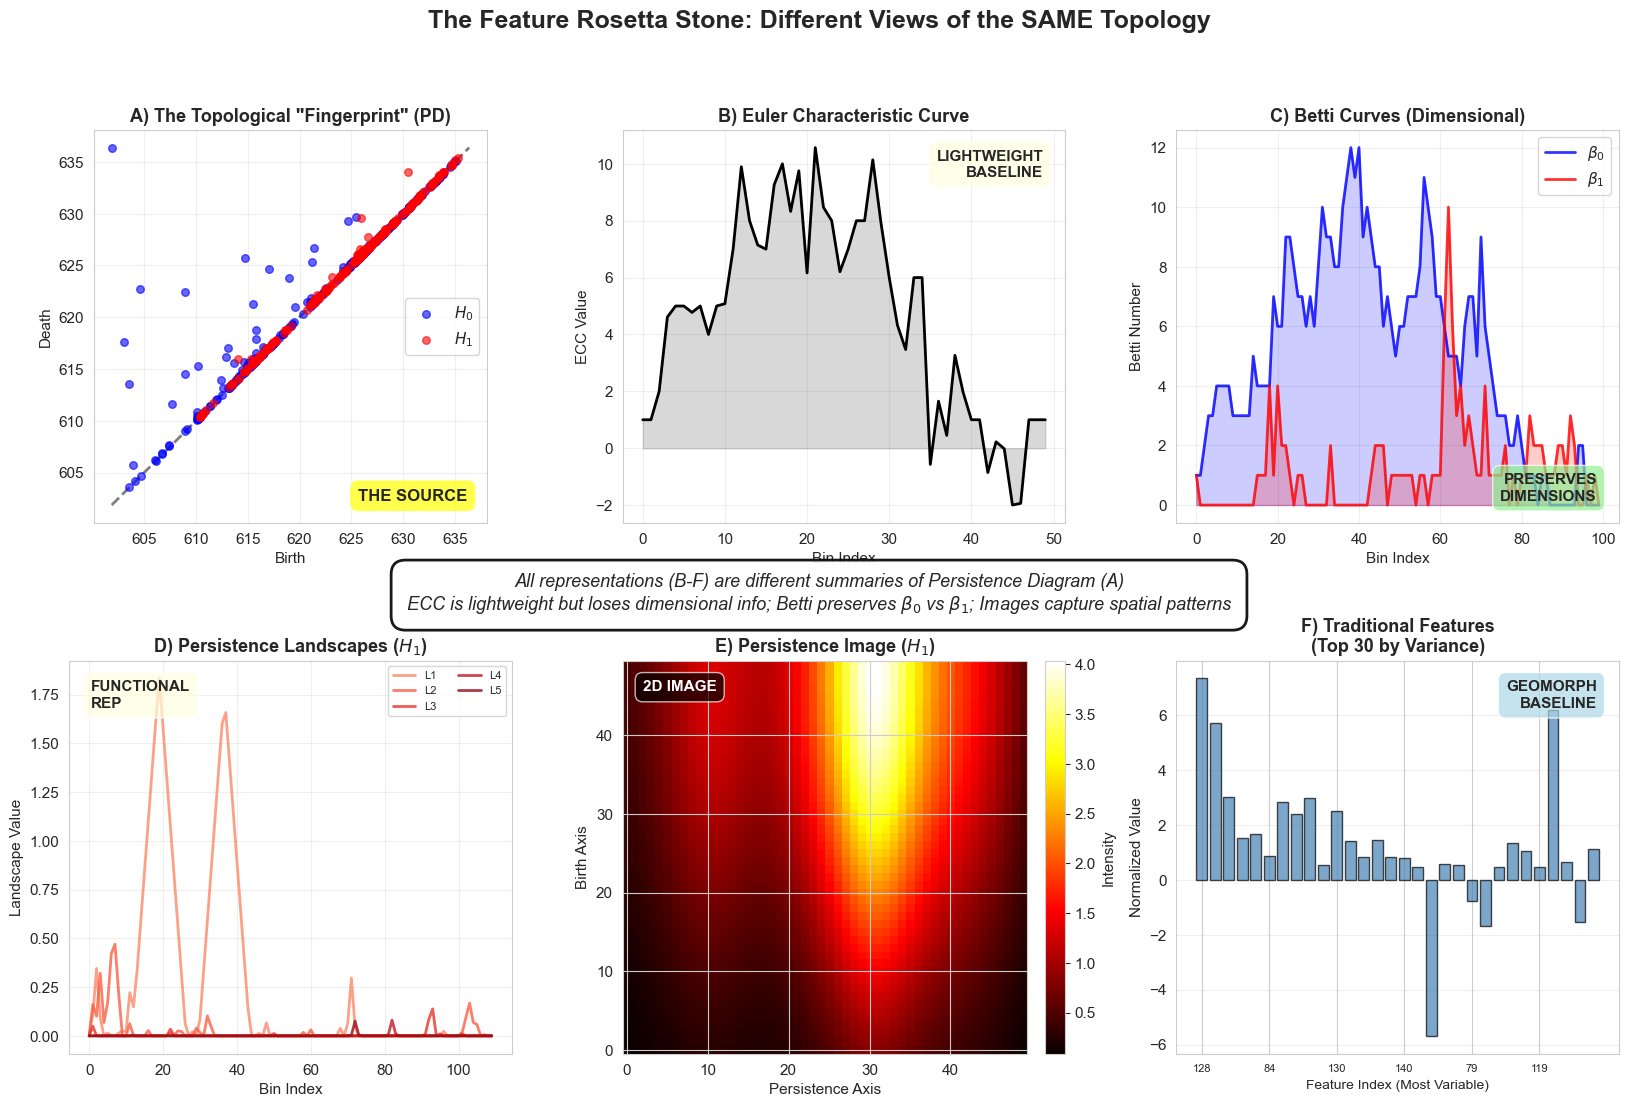

In [17]:
# Create 2x3 grid
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.25)

# A) Persistence Diagram
ax1 = fig.add_subplot(gs[0, 0])
if len(h0_pairs) > 0 or len(h1_pairs) > 0:
    ax1.scatter(h0_pairs['birth'], h0_pairs['death'], alpha=0.6, s=30, c='blue', label='$H_0$', zorder=3)
    ax1.scatter(h1_pairs['birth'], h1_pairs['death'], alpha=0.6, s=30, c='red', label='$H_1$', zorder=3)
else:
    # Show empty diagram with note
    ax1.text(0.5, 0.5, 'No valid features\n(using pre-computed\nfeatures for display)', 
            transform=ax1.transAxes, ha='center', va='center', fontsize=12, style='italic')
ax1.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, linewidth=2, zorder=1)
ax1.set_xlabel('Birth')
ax1.set_ylabel('Death')
ax1.set_title('A) The Topological "Fingerprint" (PD)', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_aspect('equal')
ax1.text(0.95, 0.05, 'THE SOURCE', transform=ax1.transAxes, fontsize=12, fontweight='bold', ha='right', va='bottom',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7))

# B) ECC - use pre-computed features
ax2 = fig.add_subplot(gs[0, 1])
ecc_precomputed = exemplar_features['ecc50']
x_ecc = np.arange(len(ecc_precomputed))
ax2.plot(x_ecc, ecc_precomputed, 'k-', linewidth=2)
ax2.fill_between(x_ecc, ecc_precomputed, alpha=0.3, color='gray')
ax2.set_xlabel('Bin Index')
ax2.set_ylabel('ECC Value')
ax2.set_title('B) Euler Characteristic Curve', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.text(0.95, 0.95, 'LIGHTWEIGHT\nBASELINE', transform=ax2.transAxes, fontsize=11, fontweight='bold', ha='right', va='top',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', alpha=0.7))

# C) Betti Curves - use pre-computed features
ax3 = fig.add_subplot(gs[0, 2])
betti_precomputed = exemplar_features['betti100']
n_dims = 2  # H0 and H1
n_bins = len(betti_precomputed) // n_dims
betti_h0 = betti_precomputed[:n_bins]
betti_h1 = betti_precomputed[n_bins:2*n_bins]
x_betti = np.arange(len(betti_h0))
ax3.plot(x_betti, betti_h0, 'b-', linewidth=2, label='$\\beta_0$', alpha=0.8)
ax3.plot(x_betti, betti_h1, 'r-', linewidth=2, label='$\\beta_1$', alpha=0.8)
ax3.fill_between(x_betti, betti_h0, alpha=0.2, color='blue')
ax3.fill_between(x_betti, betti_h1, alpha=0.2, color='red')
ax3.set_xlabel('Bin Index')
ax3.set_ylabel('Betti Number')
ax3.set_title('C) Betti Curves (Dimensional)', fontsize=13, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.text(0.95, 0.05, 'PRESERVES\nDIMENSIONS', transform=ax3.transAxes, fontsize=11, fontweight='bold', ha='right', va='bottom',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgreen', alpha=0.7))

# D) Landscapes - use pre-computed features
ax4 = fig.add_subplot(gs[1, 0])
landscape_precomputed = exemplar_features['landscape']
# Landscapes are flattened, reshape to visualize a few layers
n_layers = 5
n_dims_landscape = 2
landscape_size = len(landscape_precomputed) // (n_layers * n_dims_landscape)
# Show H1 landscapes (second half)
h1_start = n_layers * landscape_size
landscape_h1 = landscape_precomputed[h1_start:h1_start + n_layers * landscape_size]
x_landscape = np.arange(landscape_size)
colors = plt.cm.Reds(np.linspace(0.4, 0.9, n_layers))
for i in range(n_layers):
    layer_data = landscape_h1[i * landscape_size:(i + 1) * landscape_size]
    ax4.plot(x_landscape, layer_data, linewidth=2, label=f'L{i+1}', color=colors[i], alpha=0.8)
ax4.set_xlabel('Bin Index')
ax4.set_ylabel('Landscape Value')
ax4.set_title('D) Persistence Landscapes ($H_1$)', fontsize=13, fontweight='bold')
ax4.legend(ncol=2, fontsize=8)
ax4.grid(True, alpha=0.3)
ax4.text(0.05, 0.95, 'FUNCTIONAL\nREP', transform=ax4.transAxes, fontsize=11, fontweight='bold', ha='left', va='top',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', alpha=0.7))

# E) Images - use pre-computed features
ax5 = fig.add_subplot(gs[1, 1])
persimage_precomputed = exemplar_features['persimage']
n_bins_img = 50
n_dims_img = 2
img_size = n_bins_img * n_bins_img
# Show H1 image (second half)
h1_img = persimage_precomputed[img_size:2*img_size].reshape(n_bins_img, n_bins_img)
im5 = ax5.imshow(h1_img, cmap='hot', origin='lower', aspect='auto')
plt.colorbar(im5, ax=ax5, fraction=0.046, pad=0.04, label='Intensity')
ax5.set_xlabel('Persistence Axis')
ax5.set_ylabel('Birth Axis')
ax5.set_title('E) Persistence Image ($H_1$)', fontsize=13, fontweight='bold')
ax5.text(0.05, 0.95, '2D IMAGE', transform=ax5.transAxes, fontsize=11, fontweight='bold', ha='left', va='top', color='white',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='black', alpha=0.7))

# F) Traditional - FIXED to show features with variation
ax6 = fig.add_subplot(gs[1, 2])
trad_feats_all = exemplar_features['traditional']

# Find features with non-zero variance to display
variances = np.var(features['traditional'], axis=0)
top_var_indices = np.argsort(variances)[-30:][::-1]  # Top 30 most variable features
trad_feats = trad_feats_all[top_var_indices]

# Create better labels (if we know what they are, otherwise just use indices)
feature_labels = [f"{i}" for i in top_var_indices]

ax6.bar(range(len(trad_feats)), trad_feats, color='steelblue', alpha=0.7, edgecolor='black')
ax6.set_xlabel('Feature Index (Most Variable)', fontsize=10)
ax6.set_ylabel('Normalized Value', fontsize=11)
ax6.set_title('F) Traditional Features\n(Top 30 by Variance)', fontsize=13, fontweight='bold')
ax6.grid(axis='y', alpha=0.3)
ax6.set_xticks(range(0, len(trad_feats), 5))
ax6.set_xticklabels([feature_labels[i] for i in range(0, len(trad_feats), 5)], fontsize=8)
ax6.text(0.95, 0.95, 'GEOMORPH\nBASELINE', transform=ax6.transAxes, fontsize=11, fontweight='bold', ha='right', va='top',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', alpha=0.7))

# Overall title
fig.suptitle('The Feature Rosetta Stone: Different Views of the SAME Topology', 
            fontsize=18, fontweight='bold', y=0.98)

# Central annotation - updated narrative
fig.text(0.5, 0.48, 
        'All representations (B-F) are different summaries of Persistence Diagram (A)\n' +
        'ECC is lightweight but loses dimensional info; Betti preserves $\\beta_0$ vs $\\beta_1$; Images capture spatial patterns',
        ha='center', fontsize=13, style='italic',
        bbox=dict(boxstyle='round,pad=0.8', facecolor='white', alpha=0.9, edgecolor='black', linewidth=2))

plt.savefig(OUTPUT_DIR / f"{EXEMPLAR_TILE_ID}_feature_rosetta_stone.png", dpi=300, bbox_inches='tight')
print(f"✓ Saved: {EXEMPLAR_TILE_ID}_feature_rosetta_stone.png")
plt.show()

---

## Phase 4: Act III - The Payoff

**Goal:** Prove the method is accurate AND efficient

### Visual 6: Performance Bar Chart

Creating Performance Bar Chart...
✓ Saved: performance_comparison.png


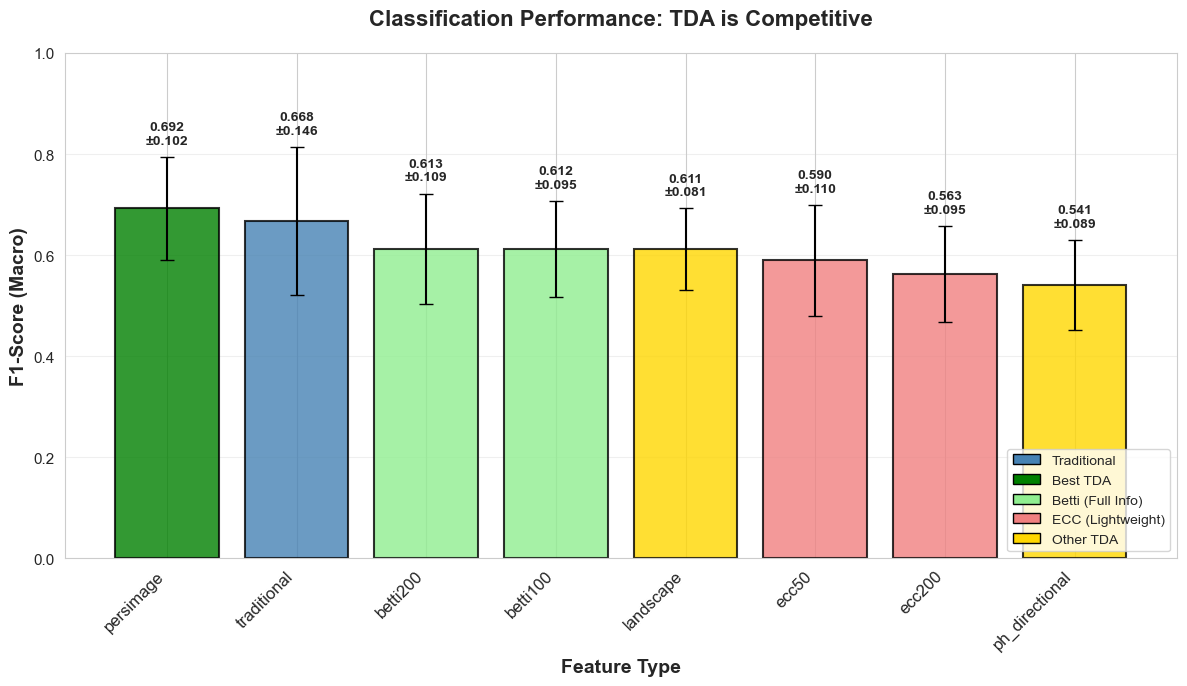

In [18]:
if f1_scores is not None:
    print("Creating Performance Bar Chart...")
    
    # Sort methods by F1 score
    methods_sorted = sorted(f1_scores.keys(), key=lambda k: f1_scores[k]['mean'], reverse=True)
    means_sorted = [f1_scores[ft]['mean'] for ft in methods_sorted]
    stds_sorted = [f1_scores[ft]['std'] for ft in methods_sorted]
    
    # Assign colors using METHOD_COLORS mapping
    colors = [METHOD_COLORS.get(ft, 'gray') for ft in methods_sorted]
    
    # Create bar chart
    fig, ax = plt.subplots(figsize=(12, 7))
    x_pos = np.arange(len(methods_sorted))
    bars = ax.bar(x_pos, means_sorted, yerr=stds_sorted, color=colors, 
                  edgecolor='black', linewidth=1.5, capsize=5, alpha=0.8)
    
    ax.set_ylabel('F1-Score (Macro)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Feature Type', fontsize=14, fontweight='bold')
    ax.set_title('Classification Performance: TDA is Competitive', fontsize=16, fontweight='bold', pad=20)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(methods_sorted, rotation=45, ha='right', fontsize=12)
    ax.set_ylim(0, 1.0)
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar, mean, std in zip(bars, means_sorted, stds_sorted):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.02,
               f'{mean:.3f}\n±{std:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # Create legend
    legend_elements = [
        Patch(facecolor='steelblue', edgecolor='black', label='Traditional'),
        Patch(facecolor='green', edgecolor='black', label='Best TDA'),
        Patch(facecolor='lightgreen', edgecolor='black', label='Betti (Full Info)'),
        Patch(facecolor='lightcoral', edgecolor='black', label='ECC (Lightweight)'),
        Patch(facecolor='gold', edgecolor='black', label='Other TDA')
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=10)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "performance_comparison.png", dpi=300, bbox_inches='tight')
    print("✓ Saved: performance_comparison.png")
    plt.show()
else:
    print("⚠ F1 scores not available")

### Visual 7: Feasibility Chart (Timing)

Creating Feasibility Chart...
✓ Saved: timing_feasibility.png


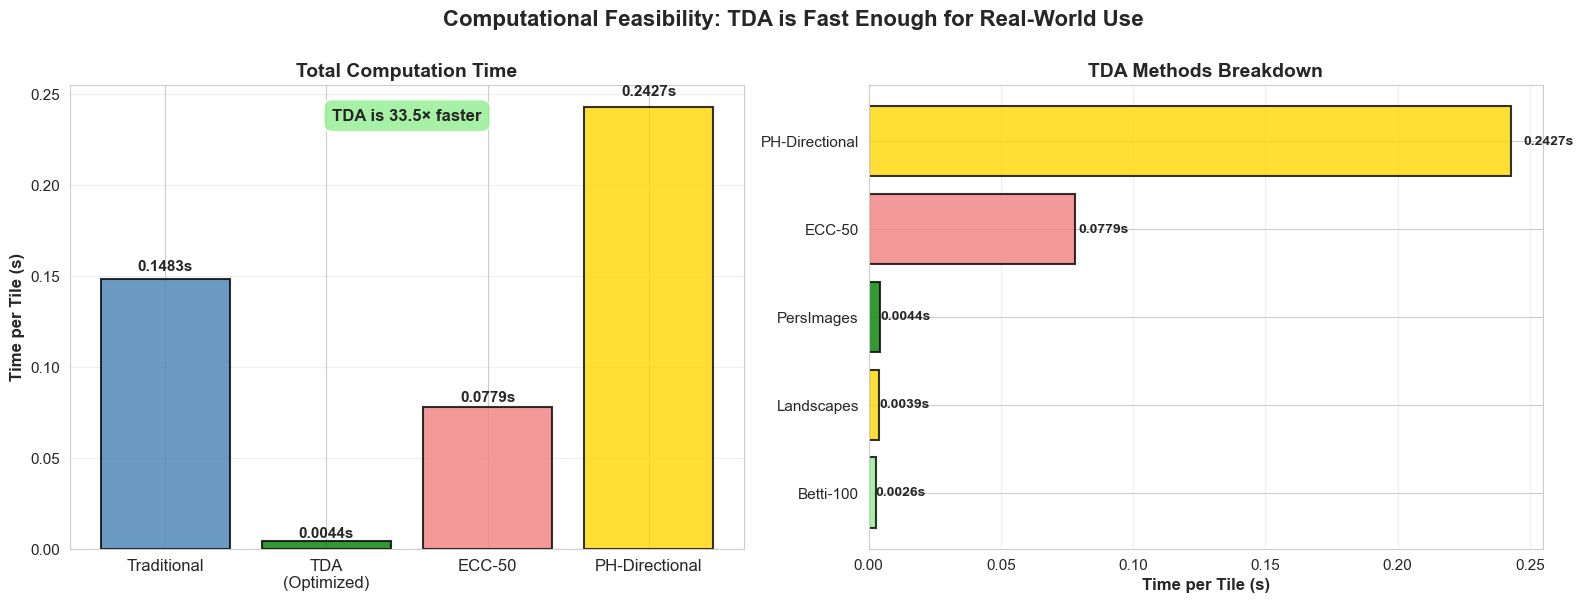

In [19]:
if timing_data is not None:
    print("Creating Feasibility Chart...")
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # LEFT: Comparison of key methods
    comparison_methods = [
        ('Traditional', 'traditional', 'steelblue'),
        ('TDA\n(Optimized)', 'persimage', 'green'),
        ('ECC-50', 'ecc50', 'lightcoral'),
        ('PH-Directional', 'ph_directional', 'gold')
    ]
    
    types, times, cols = [], [], []
    for label, key, color in comparison_methods:
        if key in timing_data:
            types.append(label)
            times.append(get_mean_time(timing_data[key]))
            cols.append(color)
    
    x_pos = np.arange(len(types))
    bars = ax1.bar(x_pos, times, color=cols, edgecolor='black', linewidth=1.5, alpha=0.8)
    ax1.set_ylabel('Time per Tile (s)', fontsize=12, fontweight='bold')
    ax1.set_title('Total Computation Time', fontsize=14, fontweight='bold')
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(types, fontsize=12)
    ax1.grid(axis='y', alpha=0.3)
    
    # Add time labels
    for bar, t in zip(bars, times):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + bar.get_height()*0.02,
                f'{t:.4f}s', ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    # Speedup annotation
    if len(times) >= 2 and times[0] > 0 and times[1] > 0:
        speedup = times[0] / times[1]
        if speedup > 1:
            ax1.text(0.5, 0.95, f'TDA is {speedup:.1f}× faster', transform=ax1.transAxes,
                    ha='center', va='top', fontsize=12, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgreen', alpha=0.8))
    
    # RIGHT: TDA Methods Breakdown
    tda_methods = {
        'ecc50': ('lightcoral', 'ECC-50'),
        'betti100': ('lightgreen', 'Betti-100'),
        'landscape': ('gold', 'Landscapes'),
        'persimage': ('green', 'PersImages'),
        'ph_directional': ('gold', 'PH-Directional')
    }
    
    method_data = [
        (tda_methods[m][1], get_mean_time(timing_data.get(m, 0)), tda_methods[m][0])
        for m in tda_methods if m in timing_data
    ]
    
    # Sort by time
    method_data.sort(key=lambda x: x[1])
    labels_sorted, times_sorted, colors_sorted = zip(*method_data) if method_data else ([], [], [])
    
    y_pos = np.arange(len(labels_sorted))
    bars2 = ax2.barh(y_pos, times_sorted, color=colors_sorted, edgecolor='black', linewidth=1.5, alpha=0.8)
    ax2.set_xlabel('Time per Tile (s)', fontsize=12, fontweight='bold')
    ax2.set_title('TDA Methods Breakdown', fontsize=14, fontweight='bold')
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(labels_sorted, fontsize=11)
    ax2.grid(axis='x', alpha=0.3)
    
    # Add time labels
    for bar, t in zip(bars2, times_sorted):
        ax2.text(bar.get_width() + bar.get_width()*0.02, bar.get_y() + bar.get_height()/2,
                f'{t:.4f}s', ha='left', va='center', fontsize=10, fontweight='bold')
    
    fig.suptitle('Computational Feasibility: TDA is Fast Enough for Real-World Use', 
                fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "timing_feasibility.png", dpi=300, bbox_inches='tight')
    print("✓ Saved: timing_feasibility.png")
    plt.show()
else:
    print("⚠ Timing data not available")

### Visual 8 (Optional): Feature Importance Heatmap

Creating Feature Importance Heatmap...
  Model trained: Acc=0.650
✓ Saved: feature_importance_heatmap.png


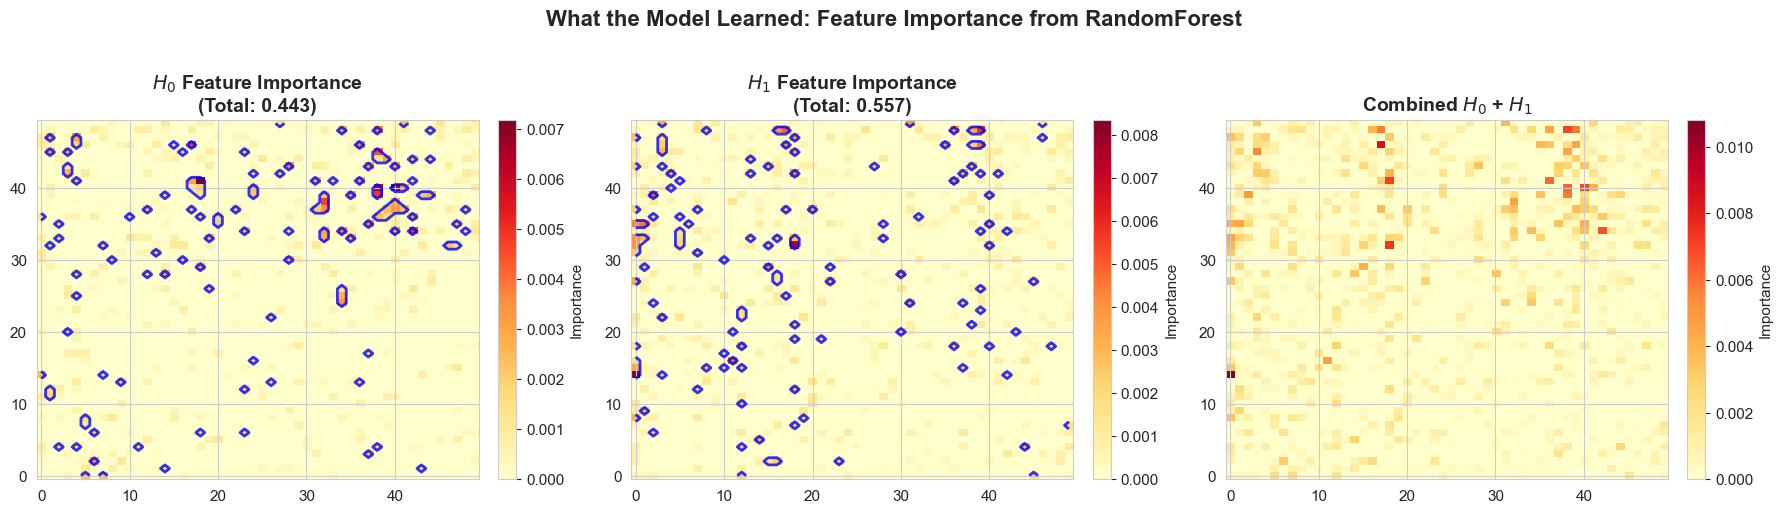

In [20]:
if 'persimage' in features and labels_all is not None:
    print("Creating Feature Importance Heatmap...")
    
    X = features['persimage']
    y = np.argmax(labels_all, axis=1)
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    print(f"  Model trained: Acc={rf.score(X_test, y_test):.3f}")
    
    importances = rf.feature_importances_
    n_bins = 50
    imp_h0 = importances[:n_bins*n_bins].reshape(n_bins, n_bins)
    imp_h1 = importances[n_bins*n_bins:].reshape(n_bins, n_bins)
    
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
    
    # H0
    im1 = ax1.imshow(imp_h0, cmap='YlOrRd', origin='lower', aspect='auto')
    plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04, label='Importance')
    ax1.set_title(f'$H_0$ Feature Importance\n(Total: {imp_h0.sum():.3f})', fontsize=14, fontweight='bold')
    ax1.contour(imp_h0 > np.percentile(imp_h0, 95), levels=[0.5], colors='blue', linewidths=2, alpha=0.8)
    
    # H1
    im2 = ax2.imshow(imp_h1, cmap='YlOrRd', origin='lower', aspect='auto')
    plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04, label='Importance')
    ax2.set_title(f'$H_1$ Feature Importance\n(Total: {imp_h1.sum():.3f})', fontsize=14, fontweight='bold')
    ax2.contour(imp_h1 > np.percentile(imp_h1, 95), levels=[0.5], colors='blue', linewidths=2, alpha=0.8)
    
    # Combined
    imp_combined = imp_h0 + imp_h1
    im3 = ax3.imshow(imp_combined, cmap='YlOrRd', origin='lower', aspect='auto')
    plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04, label='Importance')
    ax3.set_title('Combined $H_0$ + $H_1$', fontsize=14, fontweight='bold')
    
    fig.suptitle('What the Model Learned: Feature Importance from RandomForest', 
                fontsize=16, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "feature_importance_heatmap.png", dpi=300, bbox_inches='tight')
    print("✓ Saved: feature_importance_heatmap.png")
    plt.show()
else:
    print("⚠ Skipping feature importance")